# Comprensió de les dades

Realitza els passos necessaris per entendre millor les dades.

Ometem el pas de la recollida de dades perquè et proporciono totes les dades necessàries.

## Imports

In [1]:
# Importa les biblioteques, funcions, objectes... necessaris

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

## Carrega el dataset

In [2]:
df = pd.read_csv('../data/house_pricing/house_pricing.csv')

## Descriu les dades

Fes una primera inspecció bàsica de les dades: dimensions, primeres files, tipus de columnes, etc.

In [3]:
df.shape

(992, 37)

In [4]:
df.head()

,Split,Id,MSZoning,LotArea,Street,Utilities,LandSlope,HouseStyle,YearBuilt,YearRemodAdd,...,GarageFinish,GarageCars,GarageArea,PavedDrive,OpenPorchSF,EnclosedPorch,PoolArea,MiscFeature,SalePrice,Electtrical
0,labeled,1,RL,6173,Pave,AllPub,Gtl,1Story,1967.0,1967,...,Unf,1,288,Y,0,0,0,NaN,125500.0,NaN
1,labeled,2,RL,11200,Pave,AllPub,Gtl,1Story,1985.0,1985,...,Unf,2,403,Y,26,0,0,NaN,180000.0,NaN
2,labeled,3,RL,11924,Pave,AllPub,Gtl,2Story,2005.0,2006,...,Fin,3,736,Y,21,0,0,NaN,345000.0,NaN
3,labeled,4,RM,6882,Pave,AllPub,Gtl,2Story,1914.0,2006,...,NaN,0,0,Y,0,115,0,NaN,127000.0,NaN
4,labeled,5,RL,4280,Pave,AllPub,Gtl,1Story,1913.0,2002,...,Unf,1,352,P,0,34,0,NaN,90350.0,NaN


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 992 entries, 0 to 991
Data columns (total 37 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Split          992 non-null    object 
 1   Id             992 non-null    int64  
 2   MSZoning       992 non-null    object 
 3   LotArea        992 non-null    int64  
 4   Street         992 non-null    object 
 5   Utilities      992 non-null    object 
 6   LandSlope      992 non-null    object 
 7   HouseStyle     992 non-null    object 
 8   YearBuilt      992 non-null    float64
 9   YearRemodAdd   992 non-null    int64  
 10  RoofStyle      992 non-null    object 
 11  Foundation     992 non-null    object 
 12  TotalBsmtSF    992 non-null    int64  
 13  Heating        992 non-null    object 
 14  CentralAir     992 non-null    object 
 15  Electrical     961 non-null    object 
 16  1stFlrSF       992 non-null    int64  
 17  2ndFlrSF       992 non-null    int64  
 18  GrLivArea 

In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Id,992.0,496.500000,286.510035,1.0,248.75,496.5,744.25,992.0
LotArea,992.0,9410.156250,7785.723978,1300.0,7195.00,9019.0,10833.75,164660.0
YearBuilt,992.0,1971.371976,28.455495,1875.0,1955.00,1971.0,1999.00,2009.0
YearRemodAdd,992.0,1983.533266,20.467614,1950.0,1965.00,1991.0,2003.00,2010.0
TotalBsmtSF,992.0,984.961694,359.197354,0.0,780.00,941.0,1187.25,3206.0
1stFlrSF,992.0,1075.716734,314.548034,438.0,848.00,1026.0,1252.00,2259.0
2ndFlrSF,992.0,307.084677,397.709845,0.0,0.00,0.0,684.00,1440.0
GrLivArea,992.0,1386.252016,418.581680,438.0,1066.50,1344.0,1647.00,3395.0
BsmtFullBath,992.0,0.393145,0.498912,0.0,0.00,0.0,1.00,2.0
FullBath,992.0,1.496976,0.525813,0.0,1.00,1.0,2.00,3.0


La columna YearBuilt és de tipus float. Hi ha algun valor nul o algun decimal diferent de 0?

In [7]:
# Amb el mòdul 1 mirem si hi ha valors decimals (en tal cas el mòdul seria decimal)
df['YearBuilt'].isna().any() or (df['YearBuilt'] % 1 != 0).any()

np.False_

Com que no és el cas, podem convertir-la a int.

In [8]:
df['YearBuilt'] = df['YearBuilt'].astype(int)

El mateix per a `GarageYrBlt` i `SalePrice`, però s'han de mantenir com a float pels NaNs (que són float en numpy).

In [9]:
(df['GarageYrBlt'].dropna() % 1 != 0).any()

np.False_

In [10]:
(df['SalePrice'].dropna() % 1 != 0).any()

np.False_

## Anàlisi exploratòria de dades (EDA)

Resumeix les principals característiques de les dades amb visualitzacions.

### Data Profiling automàtic

In [11]:
from data_profiling import ProfileReport

In [12]:
profile = ProfileReport(
    df,
    title="House Pricing Report",
    explorative=True,  # Manté actives les anàlisis útils de text/tipus
    interactions={
        "continuous": False  # Desactiva la graella massiva de scatter plots per parells
    },
    correlations={
        "pearson": {
            "calculate": True,
            "threshold": 0.85
        },
        # Desactiva completament les alertes de mètriques de fons automàtiques
        "auto": {"calculate": False, "warn_high_correlations": False},
    },
)

In [14]:
profile.to_file('../reports/house_pricing_report.html')

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

### Distribucions de les característiques

Comprova les distribucions de les característiques numèriques (histograma o boxplot) i de les característiques categòriques (gràfic de barres).

Només 1 pool area diferent de 0, no és una característica útil. Podem eliminar aquesta columna durant el processament.

In [10]:
df['PoolArea'].value_counts()

PoolArea
0      991
519      1
Name: count, dtype: int64

El mateix passa amb `Utilities`:

In [11]:
df['Utilities'].value_counts()

Utilities
AllPub    991
NoSeWa      1
Name: count, dtype: int64

Hi havia una acumulació estranya a l'histograma de YearBuilt amb valors >= 2000. En comprovar-ho amb value_counts, tot sembla correcte.

In [12]:
df[df['YearBuilt'] >= 2000]['YearBuilt'].value_counts()

YearBuilt
2005    51
2004    39
2006    32
2007    27
2003    25
2002    20
2000    18
2008    11
2009    10
2001    10
Name: count, dtype: int64

Algunes de les variables categòriques tenen molt poques categories.

Després de revisar-les (codi a sota), les conclusions són:

- `MSZoning` només té dos comercials... La resta estan més o menys bé.
- `LandSlope` només té uns pocs exemples de Sev slope. Probablement no té cap efecte, però la podem mantenir.
- `HouseStyle` només té 2 2.5Fin i 5 2.5Unf. Com que SLvl i SFoyer són molt similars a 1.5Fin acabat, els podem incloure allà.
- `RoofStyle` sembla útil, però només té 3 de Flat i Gambrel, que és molt poc.
- `Foundation` sembla bé tot i que té Stone amb només 4 instàncies.
- `Street` té majoritàriament Pave però també alguns Grvl. Com que tenir Grvl podria ser un indicador d'un preu més baix, la podem mantenir.
- `Heating` té majoritàriament valors GasA. El segon més freqüent és GasW amb 10... que també és gas. Probablement podem eliminar aquesta característica.
- `PavedDrive` té majoritàriament valors Y, però també alguns dels altres. Deixa'l com està de moment.
- `Electrical` té FuseF i FuseP amb molt pocs exemples. Probablement podríem crear una característica booleana que indiqui `SBrkr` o `Fuse` (amb A, F i P junts), tot i que hi ha una gran diferència entre FuseA i FuseF (potència limitada) i FuseP (risc d'incendi). Potser podem crear una categoria FuseFP que combini els dos fusibles dolents. Comprovarem els NaNs més endavant.
- `MiscFeature` només té 1 exemple de TenC i Othr, aquestes categories no són útils. Podem crear una nova columna `HasShed` en lloc d'aquesta característica.

In [13]:
to_check = [
    'MSZoning', 'LandSlope', 'HouseStyle', 'RoofStyle', 'Foundation', 'GarageType',
    'Street', 'Heating', 'PavedDrive', 'Electrical', 'MiscFeature'
]

for col in to_check:
    print(df[col].value_counts(dropna=False))
    print()

MSZoning
RL         761
RM         165
FV          52
RH          12
C (all)      2
Name: count, dtype: int64

LandSlope
Gtl    955
Mod     34
Sev      3
Name: count, dtype: int64

HouseStyle
1Story    503
2Story    290
1.5Fin     99
SLvl       48
SFoyer     33
1.5Unf     12
2.5Unf      5
2.5Fin      2
Name: count, dtype: int64

RoofStyle
Gable      821
Hip        158
Mansard      7
Gambrel      3
Flat         3
Name: count, dtype: int64

Foundation
CBlock    468
PConc     417
BrkTil     87
Slab       16
Stone       4
Name: count, dtype: int64

GarageType
Attchd     587
Detchd     285
NaN         54
BuiltIn     49
Basment     11
2Types       3
CarPort      3
Name: count, dtype: int64

Street
Pave    988
Grvl      4
Name: count, dtype: int64

Heating
GasA     973
GasW      10
Grav       5
Wall       3
Floor      1
Name: count, dtype: int64

PavedDrive
Y    921
N     56
P     15
Name: count, dtype: int64

Electrical
SBrkr    872
FuseA     70
NaN       31
FuseF     17
FuseP      2
Name: c

### Correlació entre característiques

L'única correlació alta és entre `GarageArea` i `GarageCars`, com era d'esperar. No obstant això, com que la correlació no és molt molt alta (0.87) i no tenim moltíssimes característiques, podem deixar-les totes dues.

In [14]:
corrs = df.corr(numeric_only=True)

In [15]:
corrs.loc['GarageCars', 'GarageArea']

np.float64(0.8723205110816238)

### Pairplot

Visualitza la relació entre les diferents característiques amb un pairplot.

Sembla que hi ha una correlació no lineal entre `SalesPrice` i `YearBuilt`. Els models que funcionaran millor poden ser els no lineals.

In [17]:
fts2pair = ['LotArea', 'GrLivArea', 'YearBuilt', 'GarageArea', 'SalePrice']

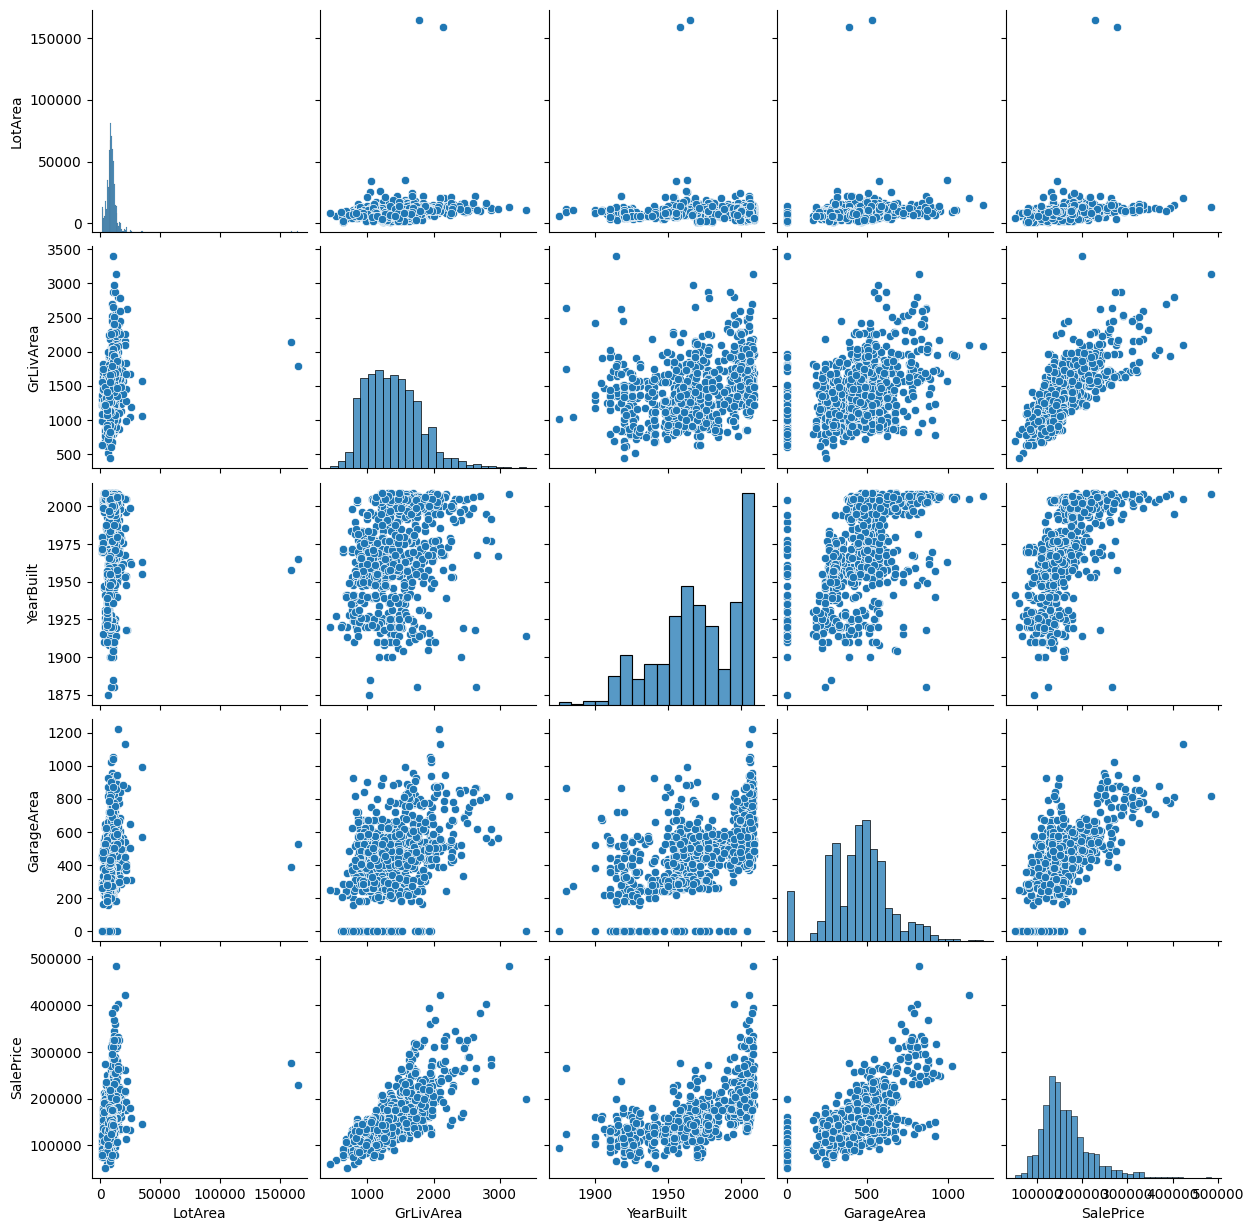

In [18]:
sns.pairplot(df[fts2pair])
plt.show()

## Verifica la qualitat de les dades

- Són correctes les dades? Conté alguna columna errors importants que s'haurien de corregir?
- I els valors absents?
    - Com es representen (p. ex., cadena buida, NaN, -1, etc.)?
    - On apareixen?
    - Com de comuns són?
- No canviïs les dades, només inspecciona on apareixen aquests problemes.

### Nuls

Conclusions després de l'anàlisi següent:

- El nul de `Electrical` probablement hauria de ser SBrkr.
- El nul de `GarageType` significa que no hi ha garatge.
- El nul de `GarageYrBlt` significa que no hi ha garatge.
- El nul de `GarageFinish` significa que no hi ha garatge.
- El nul de `MiscFeature` significa que no s'ha d'afegir res (descripció de les dades). Podem calcular una nova característica `HasShed` i eliminar aquesta.
- Els nuls de `SalePrice` corresponen a preus del leaderboard que no coneixem. Estan bé.
- `Electtrical` són tots nuls. Ni tan sols està definida a la descripció de les dades. Probablement és una característica errònia que podem eliminar.

In [ ]:
# Proporció de nuls
prop_nans = df.isna().sum(axis=0) / len(df)
prop_nans[prop_nans > 0]

És sospitós que totes les característiques del garatge tinguin la mateixa proporció de nuls.

Segons el codi de sota, totes tres funcionen conjuntament: quan una és nul·la, també ho són les altres.

Com que a la descripció s'especifica que un `GarageFinish` nul significa que no hi ha garatge, sabem que un garatge NaN significa que no hi ha garatge.

In [ ]:
# Índexs de valors nuls de GarageType
set(df[df['GarageType'].isna()].index) == set(df[df['GarageYrBlt'].isna()].index) == set(df[df['GarageFinish'].isna()].index)

Per a `Electrical`, si dibuixem `YearBuilt` per a cada categoria elèctrica, veiem que les cases més noves totes tenen el tipus SBrkr. Tots els NaNs són cases noves, així que probablement són SBrkr.

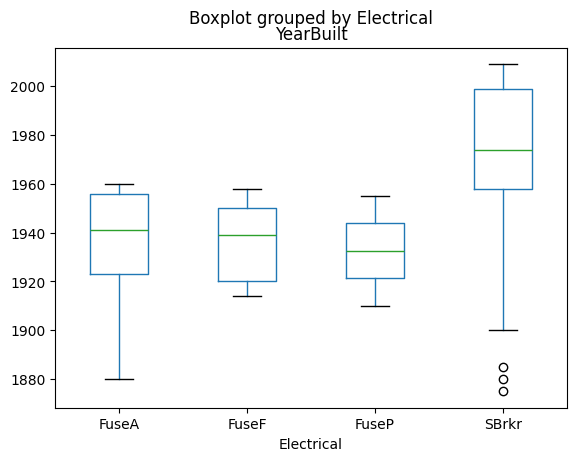

In [21]:
df.boxplot(column='YearBuilt', by='Electrical', grid=False);

In [22]:
df[df['Electrical'].isna()]['YearBuilt'].describe()

count      31.000000
mean     2005.032258
std         2.008048
min      2002.000000
25%      2003.000000
50%      2005.000000
75%      2006.500000
max      2009.000000
Name: YearBuilt, dtype: float64

Tots els nuls de `SalePrice` són del leaderboard, com s'esperava. Aquests estan bé.

In [23]:
df[df['SalePrice'].isna()]['Split'].value_counts()

Split
leaderboard    198
Name: count, dtype: int64

Molts NaNs a `MiscFeature`. Segons la descripció de les dades, això significa que no hi ha cap característica miscel·lània. Només un Othr i un TenC, no es pot aprendre res d'això. El que podem fer és canviar aquesta característica per una característica `HasShed`.

In [24]:
df['MiscFeature'].value_counts(dropna=False)

MiscFeature
NaN     952
Shed     38
Othr      1
TenC      1
Name: count, dtype: int64

### Duplicats

Cap Id duplicat (bé). Alguns duplicats després d'eliminar `Split`, `Id` i `SalePrice`. Tot i ser iguals, tenen un preu de venda diferent. Probablement podem assumir que són cases del mateix barri o similars. Encara que fossin errors (la mateixa casa afegida dues vegades amb preus diferents), com que no n'hi ha gaires, el seu impacte és mínim. Deixem-les.

In [25]:
df['Id'].duplicated().any()

np.False_

In [ ]:
# No hi ha duplicats quan eliminem Split i Id
df.drop(columns=['Split', 'Id']).duplicated().any()

np.False_

In [15]:
# Hi ha duplicats després d'eliminar aquestes columnes?
df.drop(columns=['Split', 'Id', 'SalePrice']).duplicated().any()

np.True_

In [27]:
df[df.drop(columns=['Split', 'Id', 'SalePrice']).duplicated(keep=False)].sort_values('LotArea')

,Split,Id,MSZoning,LotArea,Street,Utilities,LandSlope,HouseStyle,YearBuilt,YearRemodAdd,...,GarageFinish,GarageCars,GarageArea,PavedDrive,OpenPorchSF,EnclosedPorch,PoolArea,MiscFeature,SalePrice,Electtrical
460,labeled,461,RM,2522,Pave,AllPub,Gtl,2Story,2004,2004,...,Unf,2,380,Y,40,0,0,NaN,130000.0,NaN
734,labeled,735,RM,2522,Pave,AllPub,Gtl,2Story,2004,2004,...,Unf,2,380,Y,40,0,0,NaN,137500.0,NaN
865,leaderboard,866,FV,3180,Pave,AllPub,Gtl,2Story,2005,2005,...,RFn,2,480,Y,166,0,0,NaN,NaN,NaN
28,labeled,29,FV,3180,Pave,AllPub,Gtl,2Story,2005,2005,...,RFn,2,480,Y,166,0,0,NaN,151000.0,NaN
508,labeled,509,RM,4435,Pave,AllPub,Gtl,1Story,2003,2003,...,Fin,2,420,Y,0,0,0,NaN,131500.0,NaN
476,labeled,477,RM,4435,Pave,AllPub,Gtl,1Story,2003,2003,...,Fin,2,420,Y,0,0,0,NaN,136500.0,NaN
